In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import WordNetLemmatizer

plt.rcParams["axes.linewidth"] = 2

lemma = WordNetLemmatizer()
def lemmatizing(text):
    return lemma.lemmatize(text, pos="n")

In [3]:
df = pd.read_csv(r"..\Data\Dataset.csv")
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV,"Friends Mai, Oto and Vik's games at the park b..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
 10  description   8783 non-null   str  
dtypes: int64(1), str(10)
memory usage: 2.8 MB


In [5]:
df["date_added"] = pd.to_datetime(df["date_added"])

## ****Exploratory Data Analysis****

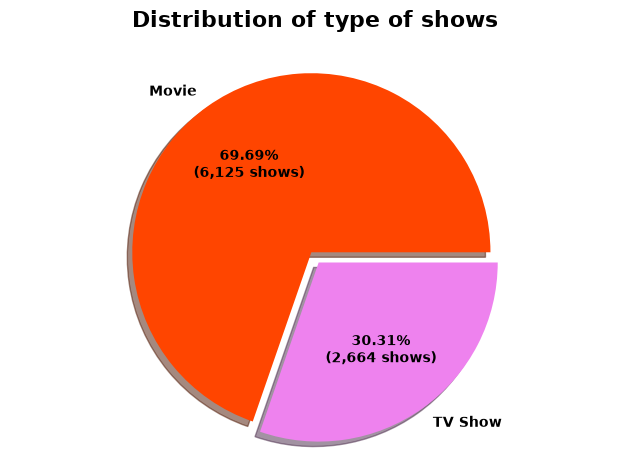

In [29]:
vc = df["type"].value_counts()
labels = ["Movie", "TV Show"]
colors = ["orangered", "violet"]

plt.pie(vc,
        labels=labels,
        colors=colors,
        shadow=True,
        autopct=lambda pct: f"{pct:.2f}%\n({int(pct/100*len(df)):,} shows)",
        startangle=360,
        textprops={"fontsize": 10, "fontweight": "bold"},
        explode=(0,0.07))
plt.title("Distribution of type of shows", fontweight="bold", fontsize=16, pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()

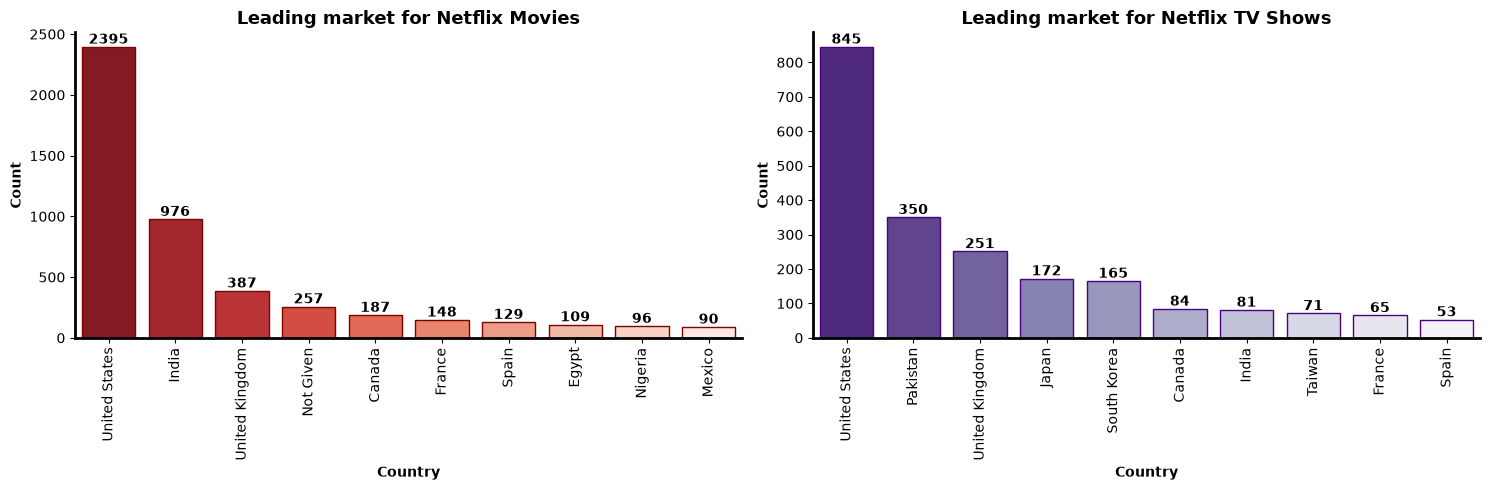

In [8]:
top_10_countries_movies = df[df["type"] == "Movie"].groupby("country")["title"].count().sort_values(ascending=False).head(10)
top_10_countries_tvshow = df[df["type"] == "TV Show"].groupby("country")["title"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 5))
plt.subplot(121)
sns.barplot(x=top_10_countries_movies.index, y=top_10_countries_movies.values, hue=top_10_countries_movies.index, palette="Reds_r", ec="maroon", legend=False)

for i, v in enumerate(top_10_countries_movies.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

plt.title("Leading market for Netflix Movies", fontweight="bold", fontsize=13)
plt.xlabel("Country", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.xticks(ticks=top_10_countries_movies.index, rotation=90)
sns.despine()

plt.subplot(122)
sns.barplot(x=top_10_countries_tvshow.index, y=top_10_countries_tvshow.values, hue=top_10_countries_tvshow.index, palette="Purples_r", ec="indigo", legend=False)

for i, v in enumerate(top_10_countries_tvshow.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

plt.title("Leading market for Netflix TV Shows", fontweight="bold", fontsize=13)
plt.xlabel("Country", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.xticks(ticks=top_10_countries_tvshow.index, rotation=90)
sns.despine()
plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


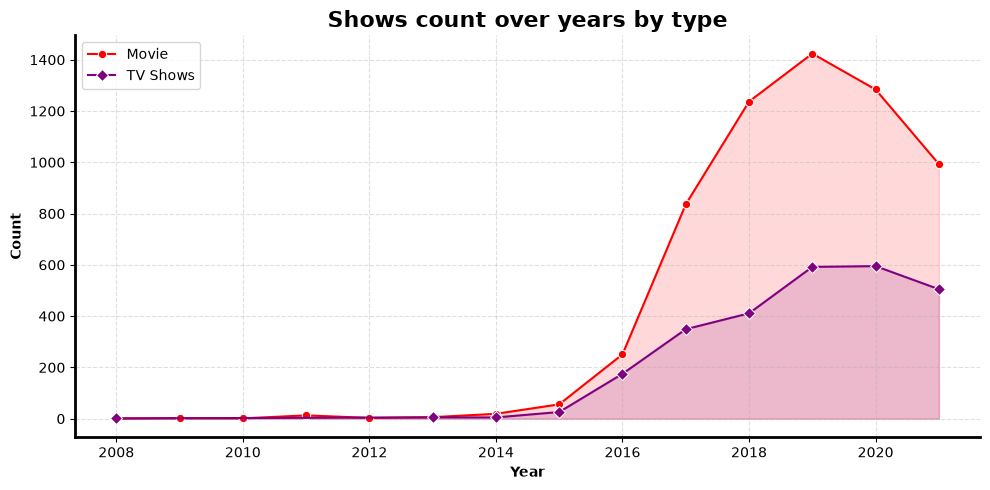

In [9]:
df["added_year"] = df["date_added"].dt.year

movies = df[df["type"] == "Movie"].groupby("added_year").size()
tvshows = df[df["type"] == "TV Show"].groupby("added_year").size()

plt.figure(figsize=(10, 5))

sns.lineplot(x=movies.index, y=movies.values, marker="o", color="red", label="Movie")
plt.fill_between(movies.index, movies.values, color="red", alpha=0.15)
sns.lineplot(x=tvshows.index, y=tvshows.values, marker="D", color="purple", label="TV Shows")
plt.fill_between(tvshows.index, tvshows.values, color="purple", alpha=0.15)
plt.title("Shows count over years by type", fontweight="bold", fontsize=16)
plt.xlabel("Year", fontweight="semibold")
plt.ylabel("Count", fontweight="semibold")
plt.grid(True, linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

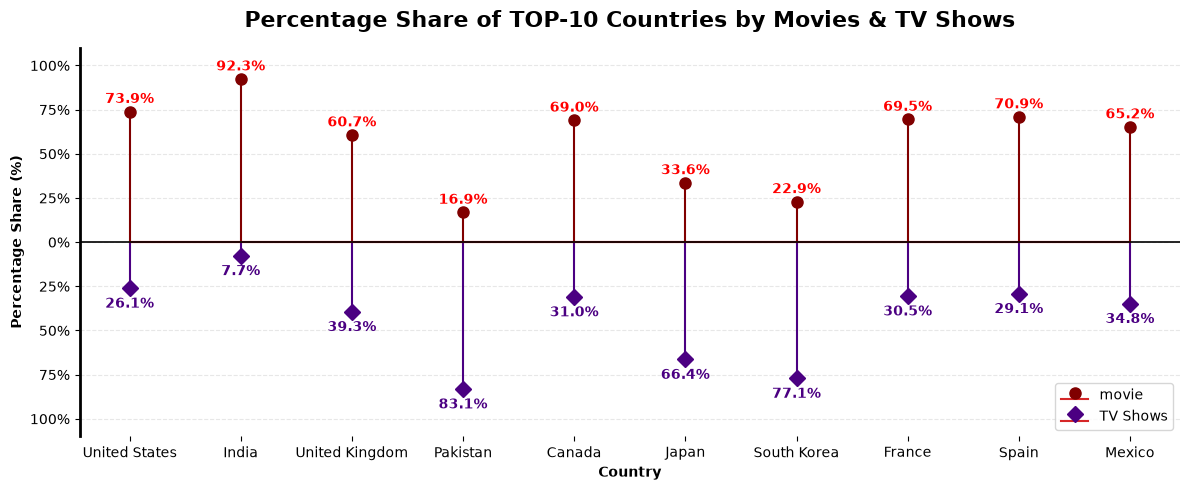

In [10]:
countrywise_watching = df[df["country"] != "Not Given"].groupby(["country", "type"])["show_id"].count().unstack(fill_value=0)
countrywise_watching["total"] = countrywise_watching.sum(axis=1)
countrywise_watching = countrywise_watching.nlargest(10, "total")
countrywise_watching["movie %"] = (countrywise_watching["Movie"] / countrywise_watching["total"])*100
countrywise_watching["tvshow %"] = (countrywise_watching["TV Show"] / countrywise_watching["total"])*100

# Plotting bidirectional stem plot
countries = countrywise_watching.index
movies_pct = countrywise_watching["movie %"]
tvshow_pct = countrywise_watching["tvshow %"]

plt.figure(figsize=(12, 5))
markerline1, stemline1, baseline = plt.stem(countries, movies_pct, linefmt="maroon", markerfmt="o", label="movie")
plt.setp(markerline1, color="maroon", markersize=8)

markerline2, stemline2, baseline = plt.stem(countries, -tvshow_pct, linefmt="indigo", markerfmt="D", label="TV Shows")
plt.setp(markerline2, color="indigo", markersize=8)

for i, (m, t) in enumerate(zip(movies_pct, tvshow_pct)):
    plt.text(i, m+3, f"{m:.1f}%", ha="center", va="bottom", fontweight="bold", color="red")

    plt.text(i, -(t+5), f"{t:.1f}%", ha="center", va="top", fontweight="bold", color="indigo")

plt.axhline(0, linewidth=1.2, color="black")
plt.xlabel("Country", fontweight="bold", fontsize=10)
plt.ylabel("Percentage Share (%)", fontweight="bold", fontsize=10)
plt.title("Percentage Share of TOP-10 Countries by Movies & TV Shows", fontweight="bold", fontsize=16, pad=15)

current_ticks = plt.yticks()[0]
plt.yticks(current_ticks, [f"{abs(y):.0f}%" for y in current_ticks])
plt.ylim(-110, 110)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine(bottom=True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

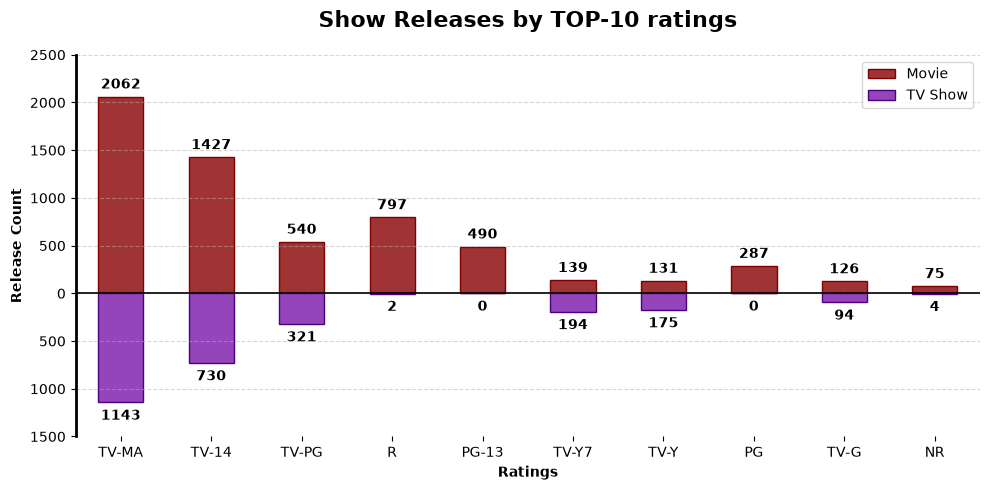

In [11]:
ratings = df.groupby(["rating", "type"])["show_id"].count().unstack(fill_value=0)
ratings["total"] = ratings.sum(axis=1)
ratings = ratings.nlargest(10, "total")

plt.figure(figsize=(10, 5))
sns.barplot(x = ratings.index, y = ratings["Movie"].values, label="Movie", color="firebrick", ec="maroon", width=0.5)
sns.barplot(x=ratings.index, y=-(ratings["TV Show"].values), label="TV Show", color="darkorchid", ec="indigo", width=0.5)
plt.axhline(0, linewidth=1.2, color="black")

for i, (m, t) in enumerate(zip(ratings["Movie"], ratings["TV Show"])):
    plt.text(i, m+50, str(m), ha="center", va="bottom", fontweight="bold", color="black")
    plt.text(i, -(t+70), str(t), ha="center", va="top", fontweight="bold", color="black")

current_count = plt.yticks()[0]
plt.yticks(current_count, [int(abs(y)) for y in current_count])
plt.ylim(-1500, 2500)
plt.title("Show Releases by TOP-10 ratings", fontweight="bold", fontsize=16, pad=20)
plt.xlabel("Ratings", fontweight="bold", fontsize=10)
plt.ylabel("Release Count", fontweight="bold", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
sns.despine(bottom=True)
plt.tight_layout()

In [12]:
movie_genre_df = df[["show_id", "title", "listed_in"]][df["type"] == "Movie"].copy()

movie_genre_df["listed_in"] = (
    movie_genre_df["listed_in"]
    .str.strip()
    .str.lower()
    .str.replace(" tv", "", regex=False)          # keep leading space
    .str.replace(" movies", "", regex=False)      # keep leading space
    .str.replace("shows", "", regex=False)
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

constraints = movie_genre_df["listed_in"].str.split().to_list()

movie_genre_df = (
    pd.DataFrame(constraints, index=movie_genre_df["title"])
    .stack()
    .reset_index()
)

movie_genre_df = (
    movie_genre_df
    .dropna()
    .drop(columns=["level_1"])
    .rename(columns={0: "Genre"})
    .reset_index(drop=True)
)

movie_genre_df["Genre"] = movie_genre_df["Genre"].apply(lemmatizing)

In [13]:
tvshow_genre_df = df[["show_id", "title", "listed_in"]][df["type"] == "TV Show"].copy()

tvshow_genre_df["listed_in"] = (
    tvshow_genre_df["listed_in"]
    .str.lower()
    .str.replace(" tv", "", regex=False)          # keep leading space
    .str.replace(" movies", "", regex=False)      # keep leading space
    .str.replace("shows", "", regex=False)
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

constraints = tvshow_genre_df["listed_in"].str.split().to_list()

tvshow_genre_df = (
    pd.DataFrame(constraints, index=tvshow_genre_df["title"])
    .stack()
    .reset_index()
)

tvshow_genre_df = (
    tvshow_genre_df
    .dropna()
    .drop(columns=["level_1"])
    .rename(columns={0: "Genre"})
    .reset_index(drop=True)
)

tvshow_genre_df["Genre"] = tvshow_genre_df["Genre"].apply(lemmatizing)

C:\Users\dell\AppData\Local\Temp\ipykernel_9928\357444613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(movie_genre, palette="Purples_r", ec="indigo")


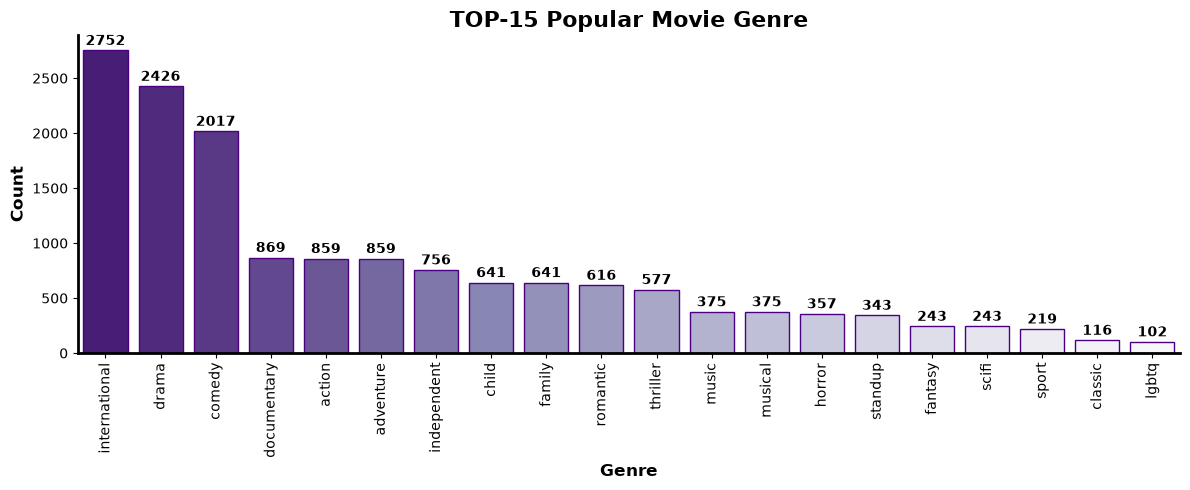

In [31]:
movie_genre = movie_genre_df.groupby("Genre").size().nlargest(20)

plt.figure(figsize=(12,5))
sns.barplot(movie_genre, palette="Purples_r", ec="indigo")

for i, v in enumerate(movie_genre.values):
    plt.text(i, v+20, str(v), ha="center", va="bottom", fontweight="bold")

plt.title("TOP-15 Popular Movie Genre", fontweight="bold", fontsize=16)
plt.xlabel("Genre", fontweight="bold", fontsize=12)
plt.ylabel("Count", fontweight="bold", fontsize=12)
plt.xticks(movie_genre.index, rotation=90)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_9928\2042873378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(tv_genre, palette="Reds_r", ec="maroon")


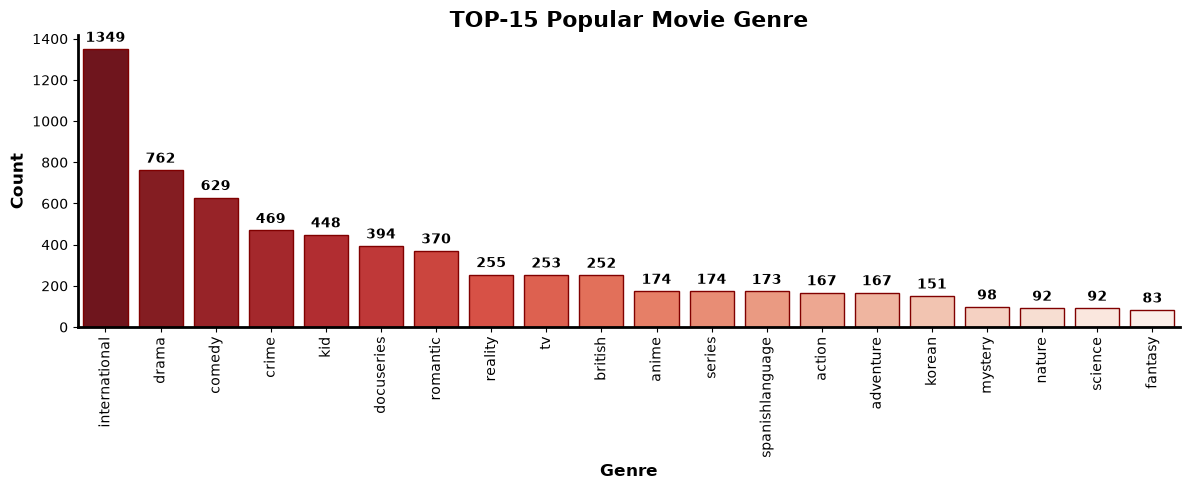

In [32]:
tv_genre = tvshow_genre_df.groupby("Genre").size().nlargest(20)

plt.figure(figsize=(12,5))
sns.barplot(tv_genre, palette="Reds_r", ec="maroon")

for i, v in enumerate(tv_genre.values):
    plt.text(i, v+20, str(v), ha="center", va="bottom", fontweight="bold")

plt.title("TOP-15 Popular Movie Genre", fontweight="bold", fontsize=16)
plt.xlabel("Genre", fontweight="bold", fontsize=12)
plt.ylabel("Count", fontweight="bold", fontsize=12)
plt.xticks(tv_genre.index, rotation=90)
sns.despine()
plt.tight_layout()
plt.show()